# Training - Part 2
## Feature Engineering / Feature Selection / Standardization / Modelling

### Load Data

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import math
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

data = pd.read_excel('DataJSK.xlsx')
data.head()

,ID,AgeJsk,GenderID,GenderName,Haredi,HarediCities,MarritalStatusID,CasherPhone,SpouseHaredi,CityID,MilitaryServiceTypeID,Military_Service,IsHasNoEducation,ChildrenUnder18,EducationLevelID,EducationLevelName,TotalChildren,Prop_Haredim
0,4326365,76,1,זכר,0,0,20,0,0,7100,3,שירות צבאי,1,4,13,ללא השכלה,4,0.027
1,4094598,74,2,נקבה,0,0,10,0,0,3000,0,ללא שירות,1,0,1,תעודת בגרות,0,0.940
2,4317349,76,1,זכר,0,0,20,0,0,5000,3,שירות צבאי,1,2,11,תיכון,5,0.037
3,4298080,74,2,נקבה,0,0,20,0,0,3000,1,שירות לאומי,0,5,5,תואר שני,5,0.415
4,4090353,75,2,נקבה,0,0,40,0,0,6400,0,ללא שירות,1,0,13,ללא השכלה,4,0.020


## 1.Feature Engeenering

### 1.1 Age / TotalChildren

In [16]:
# I add 1 to avoid division by 0
data.TotalChildren = data.TotalChildren + 1
data['F_Age_per_Child'] = data['AgeJsk'] / (data['TotalChildren'])

# Clipping Upper outlier (100 -> 32)
clip_value = data['F_Age_per_Child'].quantile(0.95)
data['F_Age_per_Child'] = data['F_Age_per_Child'].clip(upper = clip_value)
data['F_Age_per_Child_extreme'] = (data['F_Age_per_Child'] >= clip_value).astype(int)

### 1.2 EducationLevel by Age

In [17]:
## Create order to Education 
education_importance = {0: 0, 13: 1, 14: 2, 15: 3, 16: 4, 11: 5, 9: 6, 1: 7, 12: 8, 7: 9, 8: 10, 2: 11, 3: 12, 17: 13, 4: 14,
                        10: 15, 5: 16, 6: 17}
data['EducationImportance'] = data['EducationLevelID'].map(education_importance)

In [18]:
# I add 1 to avoid division by 0
data.EducationImportance = data.EducationImportance + 1
data['F_Age_Education'] = data.AgeJsk / data.EducationImportance

# Clipping Upper outlier
clip_value2 = data['F_Age_Education'].quantile(0.95)
data['F_Age_Education'] = data['F_Age_Education'].clip(upper = clip_value2)
data['F_Age_Education_extreme'] = (data['F_Age_Education'] >= clip_value2).astype(int)

### 1.3 Create Groupe-Age Variable

In [19]:
# Create GroupeAGE Variable
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, float('inf')]
labels = ['21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '66+']
data['GroupAge'] = pd.cut(data['AgeJsk'], bins = bins, labels = labels, right = True)

## 2. Features Selection

### 2.1 Correaltion Heatmap - Avoid Multicoliinearity

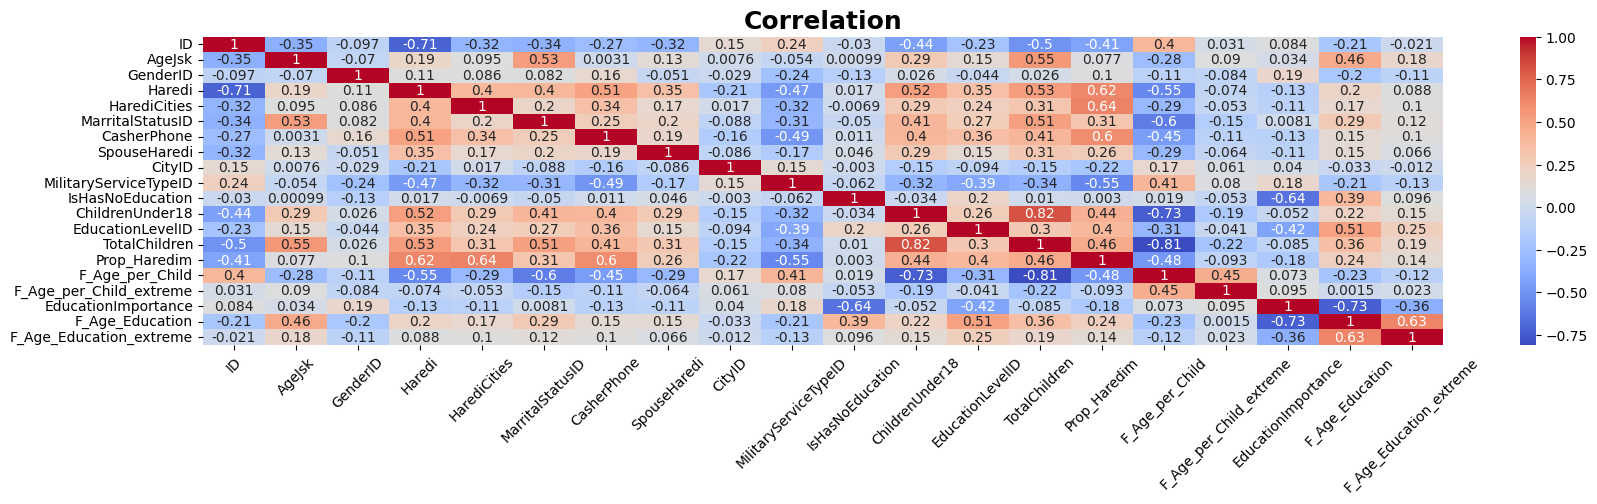

In [20]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[numerical_cols].corr()

plt.figure(figsize=(20, 4))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', cbar = True)
plt.title('Correlation', fontsize = 18, fontweight='bold')
plt.xticks(rotation = 45)
plt.show()

In [21]:
# Final Featureto keep for our model
features_to_use = [ 'Prop_Haredim', 'CasherPhone', 'HarediCities', 'F_Age_per_Child_extreme', 'F_Age_Education_extreme',
                    'MilitaryServiceTypeID','F_Age_Education', 'F_Age_per_Child', 'SpouseHaredi']

## 3. Standardization

In [22]:
# Splitting data into train & test split
from sklearn.model_selection import train_test_split

X = data[features_to_use] 
y = data['Haredi']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 42, test_size = 0.3)

mean = X_train.mean()
std = X_train.std()

# Standardization on differents sets (with the mean & std of the train set!)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

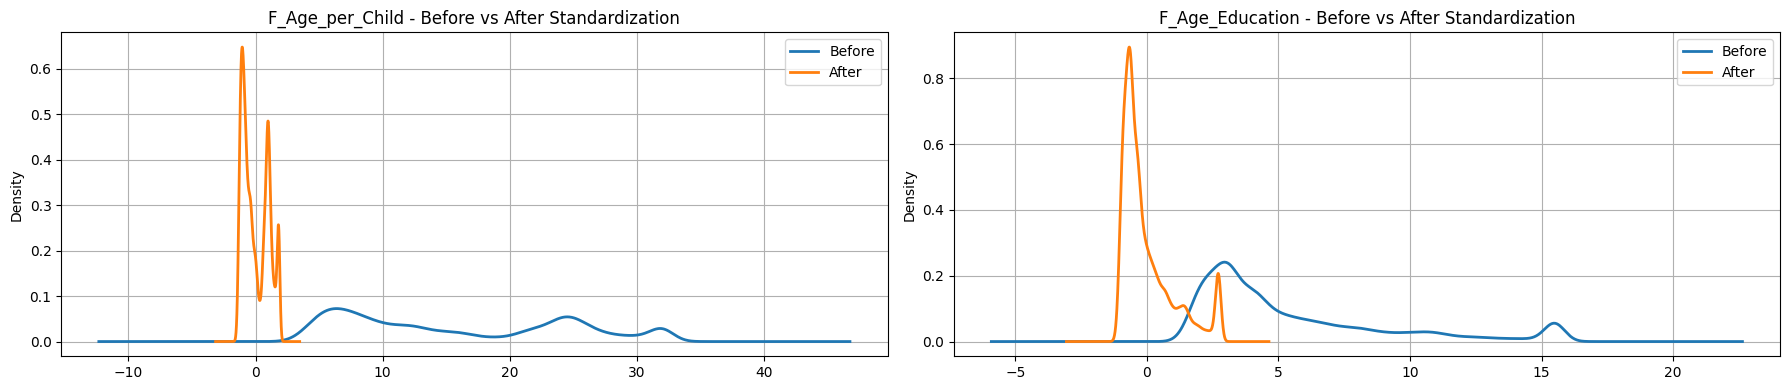

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# F_Age_per_Child
axes[0].set_title('F_Age_per_Child - Before vs After Standardization')
X_train['F_Age_per_Child'].plot(kind = 'kde', label = 'Before', ax = axes[0], linewidth = 2)
X_train_scaled['F_Age_per_Child'].plot(kind = 'kde', label = 'After', ax = axes[0], linewidth = 2)
axes[0].legend()
axes[0].grid(True)

# F_Age_Education
axes[1].set_title('F_Age_Education - Before vs After Standardization')
X_train['F_Age_Education'].plot(kind = 'kde', label = 'Before', ax = axes[1], linewidth = 2)
X_train_scaled['F_Age_Education'].plot(kind = 'kde', label = 'After', ax = axes[1], linewidth = 2)
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

# 4.Modelling

In [24]:
import torch
from torch import nn 
from torch.utils.data import DataLoader, TensorDataset, random_split

# Transform data to Tensors
X_train_tensor = torch.Tensor(X_train_scaled.to_numpy())
X_test_tensor = torch.Tensor(X_test_scaled.to_numpy())
y_train_tensor = torch.Tensor(y_train.to_numpy()).unsqueeze(1)
y_test_tensor = torch.Tensor(y_test.to_numpy()).unsqueeze(1)

# Checking if all datasets are tensor type
for dataset in [X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor]:
    if isinstance(dataset, torch.Tensor):
        continue
    else:
        print(f'{dataset} is not a tensor.')


# Combine X & y into one Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
X_train_dataloader = DataLoader(dataset = train_dataset, batch_size = 32, shuffle = True)
X_test_dataloader = DataLoader(dataset = test_dataset, batch_size = 32, shuffle = False)

In [25]:
from torchsummary import summary

class PredictHaredi(nn.Module):
    def __init__(self, hidden_neuron = 9):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features = hidden_neuron, out_features = hidden_neuron * 2),    # first layer : 9 neurons -> 18 neurons
            nn.BatchNorm1d(num_features = hidden_neuron * 2),
            nn.ReLU(),
            nn.Dropout(p = 0.5),

            nn.Linear(in_features = hidden_neuron * 2, out_features = hidden_neuron),    # second layer : 18 neurons -> 9 neurons
            nn.BatchNorm1d(num_features = hidden_neuron),
            nn.ReLU(),
            nn.Dropout(p = 0.3),

            nn.Linear(in_features = hidden_neuron, out_features = hidden_neuron // 2),   # third layer : 9 neurons -> 4 neurons
            nn.BatchNorm1d(num_features = hidden_neuron // 2),
            nn.ReLU(),

            nn.Linear(in_features = hidden_neuron // 2, out_features = 1),               # fourth layer : 4 neurons -> 1 neurons
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

model = PredictHaredi()
summary(model = model, input_size = (9, ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 18]             180
       BatchNorm1d-2                   [-1, 18]              36
              ReLU-3                   [-1, 18]               0
           Dropout-4                   [-1, 18]               0
            Linear-5                    [-1, 9]             171
       BatchNorm1d-6                    [-1, 9]              18
              ReLU-7                    [-1, 9]               0
           Dropout-8                    [-1, 9]               0
            Linear-9                    [-1, 4]              40
      BatchNorm1d-10                    [-1, 4]               8
             ReLU-11                    [-1, 4]               0
           Linear-12                    [-1, 1]               5
          Sigmoid-13                    [-1, 1]               0
Total params: 458
Trainable params: 458

In [26]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [27]:
from tqdm.auto import tqdm

EPOCH = 50
loss_history = []
accuracy_history = []

for epoch in range(EPOCH):
    model.train()
    loss_metric = 0
    acc_metric = 0

    show_progress = (epoch + 1) % 5 == 0

    if show_progress:
        dataloader = tqdm(X_train_dataloader, desc=f"Epoch {epoch+1}/{EPOCH}")
    else:
        dataloader = X_train_dataloader

    for data, label in dataloader:
        predict = model(data)
        loss = criterion(predict, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_metric += loss.item()

        with torch.no_grad():
            predictions = (predict > 0.5).float()
            acc = (predictions == label).float().mean()
            acc_metric += acc.item()

    # Enregistrer les métriques à chaque epoch
    loss_history.append(loss_metric)
    accuracy_history.append(acc_metric / len(X_train_dataloader))

    if show_progress:
        tqdm.write(f"Epoch {epoch+1} - Loss: {loss_metric:.4f} - Accuracy: {acc_metric / len(X_train_dataloader):.4f}")

Epoch 5/50: 100%|██████████| 2625/2625 [00:02<00:00, 1116.40it/s]


Epoch 5 - Loss: 938.7311 - Accuracy: 0.8528


Epoch 10/50: 100%|██████████| 2625/2625 [00:02<00:00, 1115.12it/s]


Epoch 10 - Loss: 931.2320 - Accuracy: 0.8549


Epoch 15/50: 100%|██████████| 2625/2625 [00:02<00:00, 1099.26it/s]


...

Epoch 40 - Loss: 926.6747 - Accuracy: 0.8551


Epoch 45/50: 100%|██████████| 2625/2625 [00:02<00:00, 1111.93it/s]


Epoch 45 - Loss: 922.3719 - Accuracy: 0.8560


Epoch 50/50: 100%|██████████| 2625/2625 [00:02<00:00, 1114.20it/s]

Epoch 50 - Loss: 923.5243 - Accuracy: 0.8563


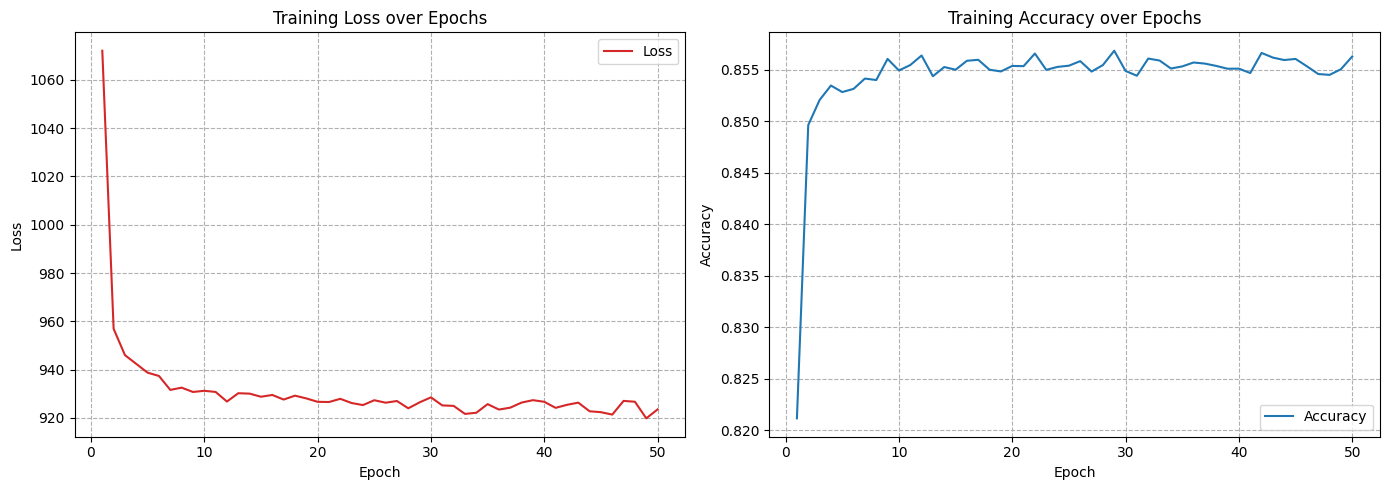

In [28]:
epochs = list(range(1, EPOCH + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Graphique de gauche : Loss
ax1.plot(epochs, loss_history, color='tab:red', label='Loss')
ax1.set_title('Training Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, ls = '--')
ax1.legend()

# Graphique de droite : Accuracy
ax2.plot(epochs, accuracy_history, color='tab:blue', label='Accuracy')
ax2.set_title('Training Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, ls = '--')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [29]:
model.eval()
with torch.no_grad():
    test_output = model(X_test_tensor)

    test_preds = (test_output >= 0.5).float()

    test_accuracy = (test_preds == y_test_tensor).float().mean().item()

print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.8636666536331177


## Metrics

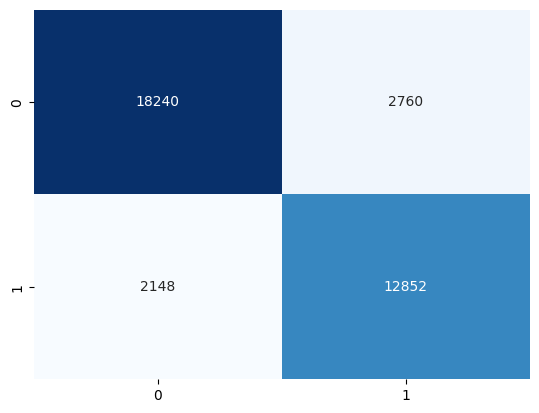

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

y_real = y_test_tensor.numpy()
cm = confusion_matrix(y_pred = test_preds, y_true = y_real)

sns.heatmap(cm, annot = True, cbar = False, fmt = 'g', cmap = 'Blues')
plt.show()

In [31]:
# Classification report - Recall and Precision
print(classification_report(y_pred = test_preds, y_true = y_real))

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88     21000
         1.0       0.82      0.86      0.84     15000

    accuracy                           0.86     36000
   macro avg       0.86      0.86      0.86     36000
weighted avg       0.86      0.86      0.86     36000



In [32]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']